In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.config import root_dir
from utils.plot_style import apply_plot_style

apply_plot_style()

In [2]:
# Load data
us_states_gdf = gpd.read_file(
    f"{root_dir}/data_input/state_boundaries/cb_2018_us_state_20m.zip!cb_2018_us_state_20m.shp"
)
aoi = gpd.read_file(f"{root_dir}results/aoi_county_boundaries.gpkg")
counties = gpd.read_file(f"{root_dir}data_input/county_demographics/nhgis0061_shape/US_county_2022.shp")
table = pd.read_csv(
    f"{root_dir}data_input/county_demographics/nhgis0061_csv/nhgis0061_ds262_20225_county.csv")

ERROR 1: PROJ: proj_create_from_database: Open of /users/2/oboiko/.conda/envs/ej/share/proj failed


In [3]:
# Data pre-processing
# Create a set of (state, county) tuples of interest
valid_pairs = set(zip(aoi["STATEFP"], aoi["COUNTYFP"]))
# Filter using a list comprehension or map
filtered_counties = counties[
    counties[["STATEFP", "COUNTYFP"]].apply(tuple, axis=1).isin(valid_pairs)
]
joined = filtered_counties.merge(table, on="GISJOIN")
# Compute population shares in one bulk operation
shares = pd.DataFrame(
    {
        "share_black": joined["AQNGE003"] / joined["AQNGE001"],
        "share_native": joined["AQNGE004"] / joined["AQNGE001"],
        "share_asian": joined["AQNGE005"] / joined["AQNGE001"],
        "share_hispanic": joined["AQNOE012"] / joined["AQNOE001"],
        "share_nonhsp_white": joined["AQNOE003"] / joined["AQNOE001"],
        "share_2_above_poverty": joined["AQPZE008"] / joined["AQPZE001"],
        "share_below_poverty": (joined["AQPZE002"] + joined["AQPZE003"])
        / joined["AQPZE001"],
    },
    index=joined.index,
)
joined = pd.concat([joined, shares], axis=1).copy()

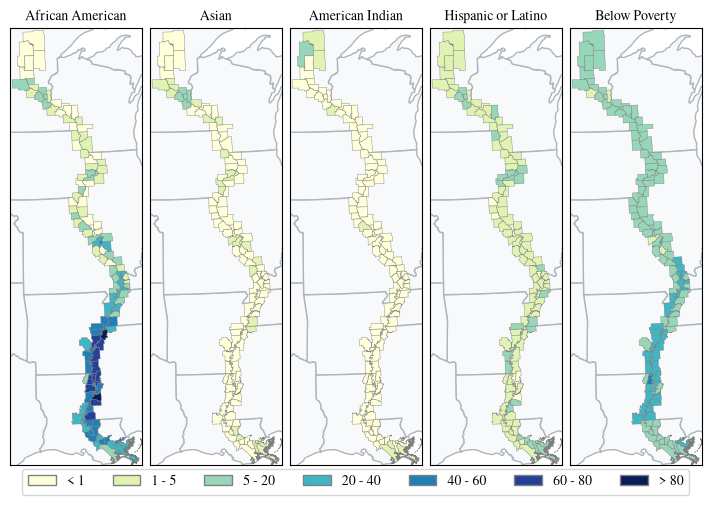

In [4]:
# Make a figure
fig, axs = plt.subplots(1, 5, figsize=(7, 5.1), layout="constrained")

variables = [
    "share_black",
    "share_asian",
    "share_native",
    "share_hispanic",
    "share_below_poverty",
]
titles = [
    "African American",
    "Asian",
    "American Indian",
    "Hispanic or Latino",
    "Below Poverty",
]
bins = dict(bins=[0.01, 0.05, 0.2, 0.4, 0.6, 0.8, 1])
labels = ["< 1", "1 - 5", "5 - 20", "20 - 40", "40 - 60", "60 - 80", "> 80"]

for index, var in enumerate(variables):
    us_states_gdf.to_crs(joined.crs).plot(
        ax=axs[index], edgecolor="#adb5bd", facecolor="#f8f9fa", lw=1.0
    )
    # is_last = (index == len(variables) - 1)
    joined.plot(
        var,
        ax=axs[index],
        cmap="YlGnBu",
        scheme="User_Defined",
        classification_kwds=bins,
        edgecolor="grey",
        lw=0.3,
        legend=False,
    )
    axs[index].set_title(titles[index])
    axs[index].set_xticks([])
    axs[index].set_yticks([])

# Set axis limits to match the bounds exactly
minx, miny, maxx, maxy = joined.total_bounds
for ax in range(5):
    axs[ax].set_xlim(minx - 10000, maxx)
    axs[ax].set_ylim(miny, maxy + 10000)

colors = plt.cm.YlGnBu(np.linspace(0, 1, len(labels)))
patches = [
    mpatches.Patch(facecolor=colors[i], label=labels[i], edgecolor="grey")
    for i in range(len(labels))
]
fig.legend(
    handles=patches,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=len(labels),
    frameon=True,
)

plt.show()

fig.savefig(f"{root_dir}/figures/Figure S1.pdf")